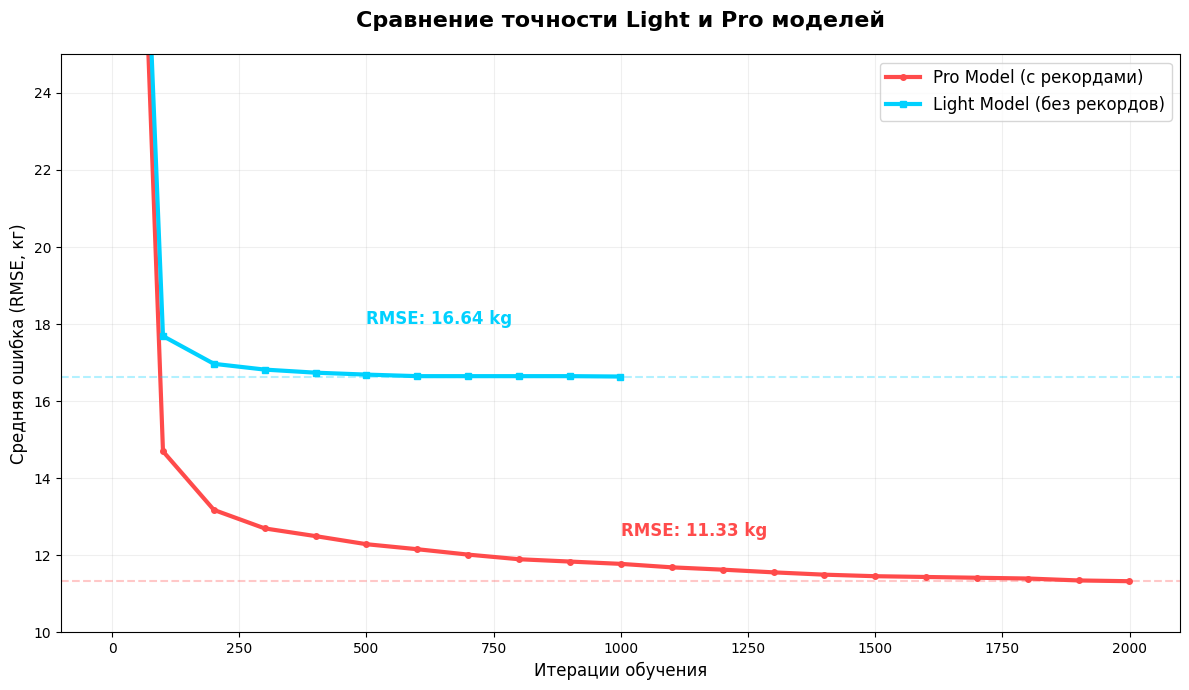

In [11]:
import matplotlib.pyplot as plt

# Данные Pro-модели из твоих логов
pro_iters = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 1999]
pro_test_rmse = [50.70, 14.70, 13.18, 12.70, 12.50, 12.29, 12.16, 12.02, 11.90, 11.84, 11.78, 11.69, 11.63, 11.56, 11.50, 11.46, 11.44, 11.42, 11.40, 11.35, 11.33]

# Данные Light-модели из твоих логов
light_iters = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999]
light_test_rmse = [50.38, 17.69, 16.97, 16.82, 16.74, 16.69, 16.65, 16.65, 16.65, 16.65, 16.64]

plt.figure(figsize=(12, 7))

# Рисуем кривые
plt.plot(pro_iters, pro_test_rmse, label='Pro Model (с рекордами)', color='#ff4b4b', linewidth=3, marker='o', markersize=4)
plt.plot(light_iters, light_test_rmse, label='Light Model (без рекордов)', color='#00d1ff', linewidth=3, marker='s', markersize=4)

# Добавляем горизонтальные линии для наглядности разницы
plt.axhline(y=11.33, color='#ff4b4b', linestyle='--', alpha=0.3)
plt.axhline(y=16.64, color='#00d1ff', linestyle='--', alpha=0.3)

# Текстовые аннотации
plt.text(1000, 12.5, 'RMSE: 11.33 kg', color='#ff4b4b', fontweight='bold', fontsize=12)
plt.text(500, 18, 'RMSE: 16.64 kg', color='#00d1ff', fontweight='bold', fontsize=12)

# Настройка осей
plt.ylim(10, 25) # Ограничим, чтобы лучше видеть разницу на плато
plt.title('Сравнение точности Light и Pro моделей', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Итерации обучения', fontsize=12)
plt.ylabel('Средняя ошибка (RMSE, кг)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

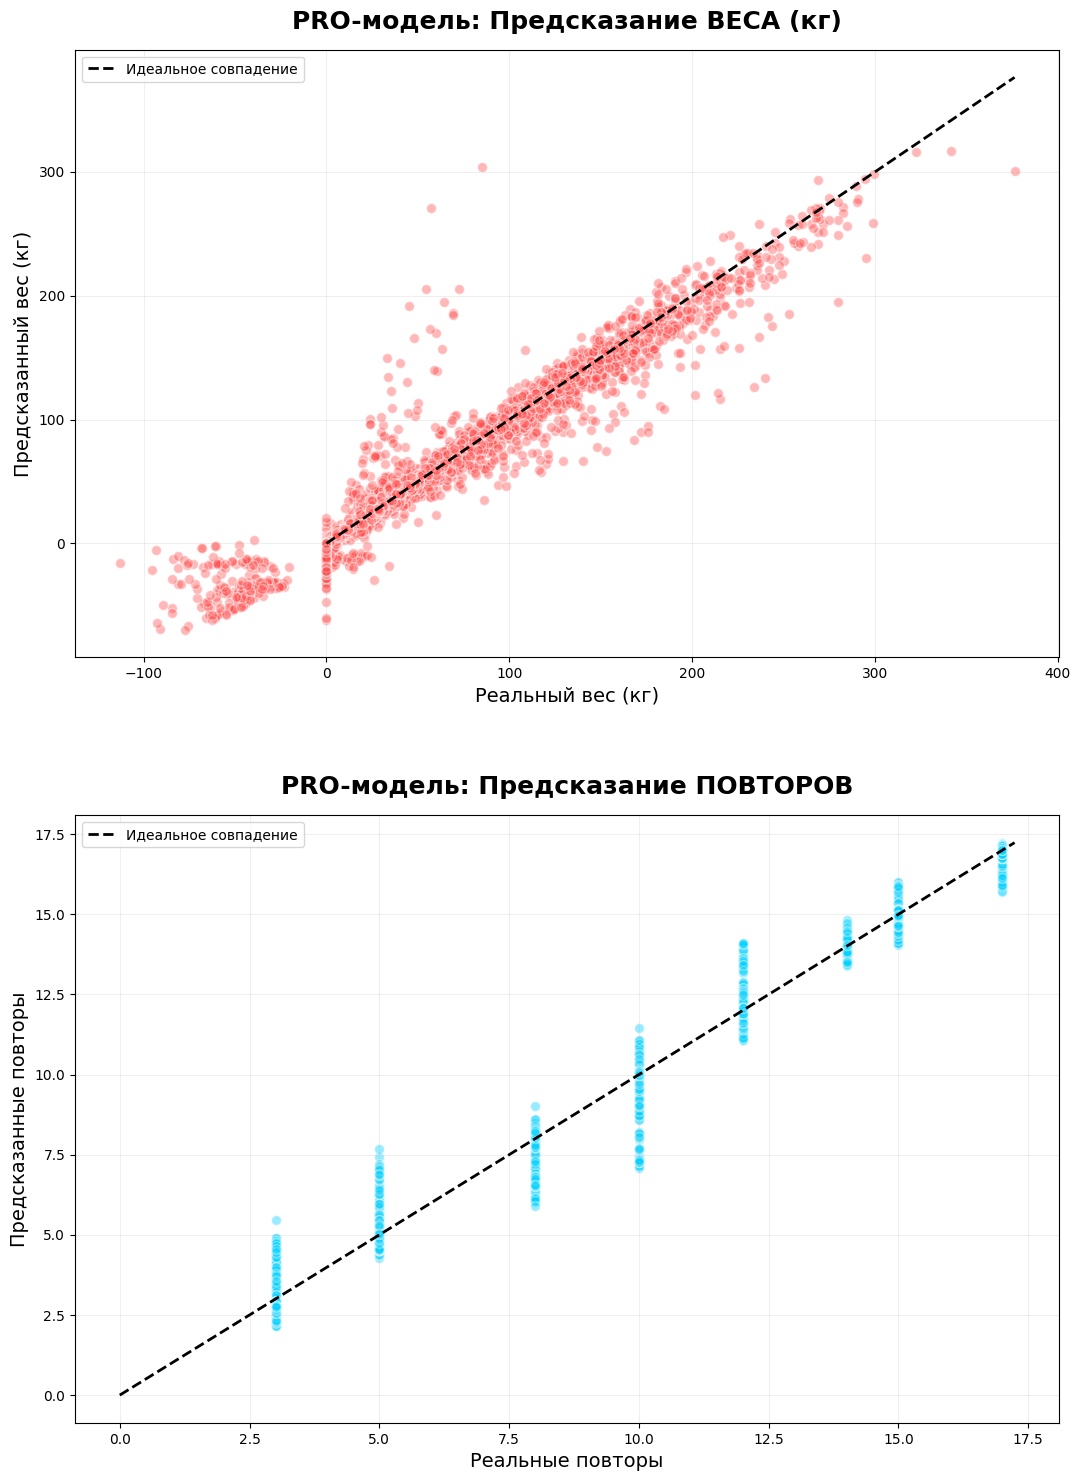

РЕЗУЛЬТАТЫ PRO-МОДЕЛИ:
Средняя ошибка по весу:   4.71 кг
Средняя ошибка по повторам: 0.20 раз


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

df_final_reg = pd.read_csv('./datasets/df_gym_pro_final.csv')
df_final_reg

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

features_pro = [
    'Sex', 'Age', 'BodyweightKg', 
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 
    'goal_clean', 'level_idx', 'Base_Lift', 'eq_clean', 'exercise_id'
]

X_pro = df_final_reg[features_pro]
Y_pro = df_final_reg[['predicted_weight', 'target_reps']]

cat_features_pro = ['Sex', 'goal_clean', 'Base_Lift', 'eq_clean', 'exercise_id']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pro, Y_pro, test_size=0.2, random_state=42
)


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. Получаем предсказания
preds_pro = model_pro.predict(X_test_p)

# Разделяем данные
weight_true = y_test_p.iloc[:, 0].values
weight_pred = preds_pro[:, 0]
reps_true = y_test_p.iloc[:, 1].values
reps_pred = preds_pro[:, 1]

# 2. Визуализация: Графики друг под другом
# Увеличиваем высоту (figsize) до 16, чтобы каждый график был по 8 в высоту
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# --- ГРАФИК 1: ВЕС (КГ) ---
ax1.scatter(weight_true, weight_pred, alpha=0.4, color='#ff4b4b', edgecolors='w', s=50)
max_w = max(weight_true.max(), weight_pred.max())
ax1.plot([0, max_w], [0, max_w], 'k--', lw=2, label='Идеальное совпадение')
ax1.set_title('PRO-модель: Предсказание ВЕСА (кг)', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Реальный вес (кг)', fontsize=14)
ax1.set_ylabel('Предсказанный вес (кг)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.2)

# --- ГРАФИК 2: ПОВТОРЫ (ШТ) ---
ax2.scatter(reps_true, reps_pred, alpha=0.4, color='#00d1ff', edgecolors='w', s=50)
max_r = max(reps_true.max(), reps_pred.max())
ax2.plot([0, max_r], [0, max_r], 'k--', lw=2, label='Идеальное совпадение')
ax2.set_title('PRO-модель: Предсказание ПОВТОРОВ', fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel('Реальные повторы', fontsize=14)
ax2.set_ylabel('Предсказанные повторы', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout(pad=5.0) # Добавляем отступ между графиками
plt.show()

# 3. Финальные метрики
mae_w = mean_absolute_error(weight_true, weight_pred)
mae_r = mean_absolute_error(reps_true, reps_pred)
print(f"\033[1mРЕЗУЛЬТАТЫ PRO-МОДЕЛИ:\033[0m")
print(f"Средняя ошибка по весу:   {mae_w:.2f} кг")
print(f"Средняя ошибка по повторам: {mae_r:.2f} раз")

--- ПРОВЕРКА LIGHT-ПРЕДСКАЗАНИЙ (TOP-10) ---
   Реальный Вес  Предсказан Вес  Реальные Повторы  Предсказ Повторы
0          28.3           37.73                 8              8.01
1           5.0            3.13                 3              2.79
2          80.0           66.99                 3              3.42
3          14.3           17.88                10             10.00
4         122.8          126.23                 3              3.17
5          14.0           11.71                17             17.11
6           8.7            8.05                10             10.17
7          75.2           71.29                 5              5.08
8         -45.8          -39.30                10             10.12
9           0.0           -0.07                15             14.85
----------------------------------------


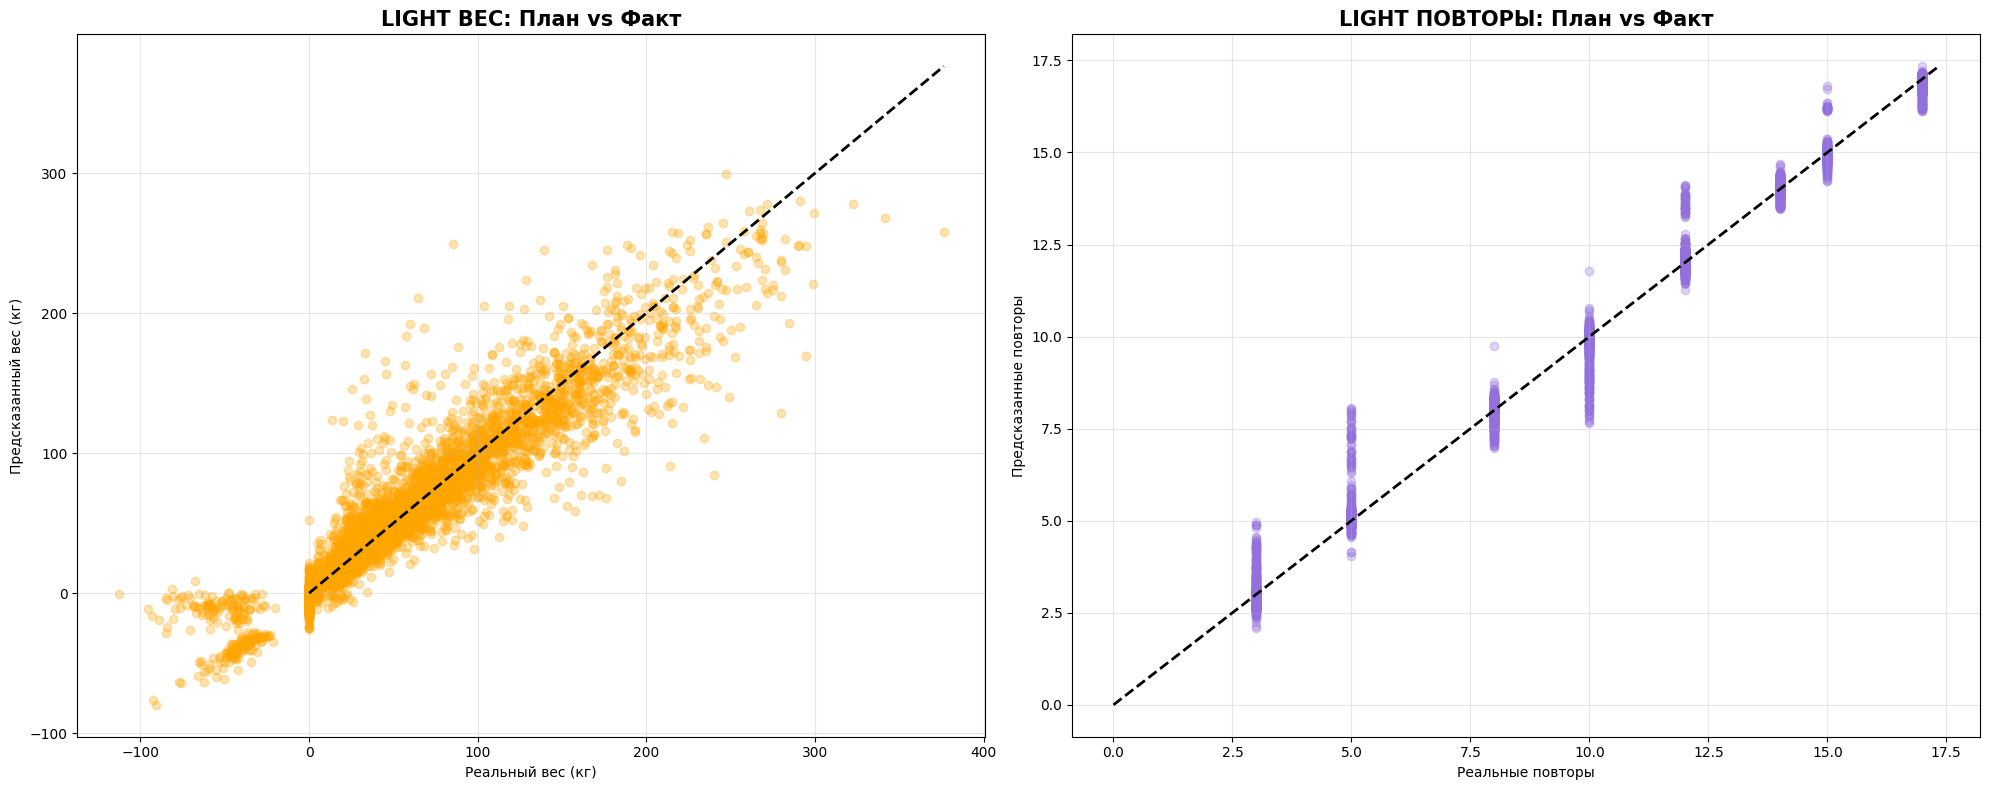

LIGHT Средняя ошибка по весу: 9.09 кг
LIGHT Средняя ошибка по повторам: 0.15 раз


In [24]:
from catboost import Pool

# 1. Подготавливаем данные в формате Pool
# Это решит проблему несовпадения типов раз и навсегда
eval_pool_light = Pool(
    data=X_test_l, 
    label=y_test_l, 
    cat_features=cat_features_light
)

# 2. ПОЛУЧЕНИЕ ПРЕДСКАЗАНИЙ
# Теперь предсказываем через Pool
preds_light = model_light.predict(eval_pool_light)

# 3. Создаем таблицу для проверки
check_df_light = pd.DataFrame({
    'Реальный Вес': y_test_l.iloc[:, 0].values,
    'Предсказан Вес': preds_light[:, 0],
    'Реальные Повторы': y_test_l.iloc[:, 1].values,
    'Предсказ Повторы': preds_light[:, 1]
})

print("--- ПРОВЕРКА LIGHT-ПРЕДСКАЗАНИЙ (TOP-10) ---")
print(check_df_light.head(10).round(2))
print("-" * 40)

# Данные для графиков
w_true_l = y_test_l.iloc[:, 0].values
w_pred_l = preds_light[:, 0]
r_true_l = y_test_l.iloc[:, 1].values
r_pred_l = preds_light[:, 1]

# --- 4. ВИЗУАЛИЗАЦИЯ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# График Веса Light (Оранжевый)
ax1.scatter(w_true_l, w_pred_l, alpha=0.3, color='#FFA500')
max_w = max(w_true_l.max(), w_pred_l.max())
ax1.plot([0, max_w], [0, max_w], 'k--', lw=2)
ax1.set_title('LIGHT-модель: предсказание веса', fontsize=15, fontweight='bold')
ax1.set_xlabel('Реальный вес (кг)')
ax1.set_ylabel('Предсказанный вес (кг)')
ax1.grid(True, alpha=0.3)

# График Повторов Light (Фиолетовый)
ax2.scatter(r_true_l, r_pred_l, alpha=0.3, color='#9370DB')
max_r = max(r_true_l.max(), r_pred_l.max())
ax2.plot([0, max_r], [0, max_r], 'k--', lw=2)
ax2.set_title('LIGHT-модель: предсказание повторов', fontsize=15, fontweight='bold')
ax2.set_xlabel('Реальные повторы')
ax2.set_ylabel('Предсказанные повторы')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. МЕТРИКИ ---
mae_w_l = mean_absolute_error(w_true_l, w_pred_l)
mae_r_l = mean_absolute_error(r_true_l, r_pred_l)
print(f"LIGHT Средняя ошибка по весу: {mae_w_l:.2f} кг")
print(f"LIGHT Средняя ошибка по повторам: {mae_r_l:.2f} раз")